In [1]:
import pandas as pd
import numpy as np
from shapely.geometry import Polygon, Point
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import geopandas as gpd
import contextily as cx
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import seaborn as sns

In [2]:
df_allDataFiltered = pd.read_csv('colombia_results_total_filtrado.csv')

In [3]:
df_allDataFiltered = df_allDataFiltered.drop(['Unnamed: 0', 'id', 'time'], axis=1)


In [4]:
# preprocessing data...

df_allDataFiltered = df_allDataFiltered[df_allDataFiltered['longitude'] >= -80]
df_allDataFiltered = df_allDataFiltered[df_allDataFiltered['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'] >= 1600]
df_allDataFiltered['longitude'] = df_allDataFiltered['longitude'].round(3)
df_allDataFiltered['latitude'] = df_allDataFiltered['latitude'].round(3)
df_allDataFiltered['coordinates'] = df_allDataFiltered.apply(lambda row: [row['longitude'], row['latitude']], axis=1)
df_allDataFiltered['date'] = pd.to_datetime(df_allDataFiltered['date'])
df_allDataFiltered

,longitude,latitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date,coordinate_x,coordinate_y,coordinates,geometry
0,-71.495,11.925,1862.269873,2019-02-08 12:02:12,[-71.495],[11.925],"[-71.495, 11.925]","POLYGON ((-71.5 11.92, -71.5 11.93000000000000..."
1,-71.745,11.915,1840.372803,2019-02-08 12:02:12,[-71.745],[11.915],"[-71.745, 11.915]","POLYGON ((-71.75 11.909999999999998, -71.75 11..."
2,-71.755,11.915,1840.372803,2019-02-08 12:02:12,[-71.755],[11.915],"[-71.755, 11.915]",POLYGON ((-71.75999999999999 11.90999999999999...
3,-71.765,11.915,1840.372803,2019-02-08 12:02:12,[-71.765],[11.915],"[-71.765, 11.915]","POLYGON ((-71.77 11.909999999999998, -71.77 11..."
4,-71.775,11.915,1840.372803,2019-02-08 12:02:12,[-71.775],[11.915],"[-71.775, 11.915]","POLYGON ((-71.78 11.909999999999998, -71.78 11..."
...,...,...,...,...,...,...,...,...
7266201,-72.435,4.525,1930.100098,2024-11-02 12:39:28,[-72.435],[4.525],"[-72.435, 4.525]","POLYGON ((-72.44 4.5200000000000005, -72.44 4...."
7266202,-72.445,4.525,1930.060781,2024-11-02 12:39:28,[-72.44500000000001],[4.525],"[-72.445, 4.525]","POLYGON ((-72.45 4.5200000000000005, -72.45 4...."
7266203,-72.455,4.525,1929.658248,2024-11-02 12:39:28,[-72.455],[4.525],"[-72.455, 4.525]","POLYGON ((-72.46 4.5200000000000005, -72.46 4...."
7266204,-72.255,4.525,1939.287932,2024-11-02 12:39:28,[-72.255],[4.525],"[-72.255, 4.525]",POLYGON ((-72.25999999999999 4.520000000000000...


In [5]:
df_clusteredMeanData = pd.read_csv('mean_values_clustered_v1.csv')

In [6]:
df_clusteredMeanData['coordinates'] = df_clusteredMeanData.apply(lambda row: [row['longitude'], row['latitude']], axis=1)

df_clusteredMeanData

,latitude,longitude,cluster,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinates
0,10.005,-75.295,0,1927.416784,"[-75.295, 10.005]"
1,9.445,-74.565,0,1930.315294,"[-74.565, 9.445]"
2,6.255,-73.205,0,1900.766561,"[-73.205, 6.255]"
3,12.285,-71.575,0,1898.016579,"[-71.575, 12.285]"
4,7.915,-75.515,0,1905.816772,"[-75.515, 7.915]"
...,...,...,...,...,...
494241,3.105,-75.175,4,1916.644395,"[-75.175, 3.105]"
494242,4.175,-74.765,4,1913.924160,"[-74.765, 4.175]"
494243,2.565,-75.675,4,1873.410937,"[-75.675, 2.565]"
494244,2.885,-75.195,4,1931.592124,"[-75.195, 2.885]"


In [7]:
aa = np.sort(df_allDataFiltered['longitude'].unique())
np.shape(aa)

(1209,)

In [8]:
bb = np.sort(df_clusteredMeanData['longitude'].unique())
np.shape(bb)

(1200,)

In [9]:
# Find values in array1 that are not in array2
diff1 = np.setdiff1d(aa, bb)
print(len(diff1))
diff1


9


array([-78.935, -78.925, -78.825, -78.485, -78.465, -78.455, -78.445,
       -77.875, -77.495])

In [10]:
latitude_difference = [-4.145, 12.435, 12.445]
longitude_difference = [-78.935, -78.925, -78.825, -78.485, -78.465, -78.455, -78.445, -77.875, -77.495]

# Filter rows where longitude is NOT in the longitude_difference list
df_allDataFiltered = df_allDataFiltered[~df_allDataFiltered['longitude'].isin(longitude_difference)]
df_allDataFiltered = df_allDataFiltered[~df_allDataFiltered['latitude'].isin(latitude_difference)]
df_allDataFiltered

,longitude,latitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date,coordinate_x,coordinate_y,coordinates,geometry
0,-71.495,11.925,1862.269873,2019-02-08 12:02:12,[-71.495],[11.925],"[-71.495, 11.925]","POLYGON ((-71.5 11.92, -71.5 11.93000000000000..."
1,-71.745,11.915,1840.372803,2019-02-08 12:02:12,[-71.745],[11.915],"[-71.745, 11.915]","POLYGON ((-71.75 11.909999999999998, -71.75 11..."
2,-71.755,11.915,1840.372803,2019-02-08 12:02:12,[-71.755],[11.915],"[-71.755, 11.915]",POLYGON ((-71.75999999999999 11.90999999999999...
3,-71.765,11.915,1840.372803,2019-02-08 12:02:12,[-71.765],[11.915],"[-71.765, 11.915]","POLYGON ((-71.77 11.909999999999998, -71.77 11..."
4,-71.775,11.915,1840.372803,2019-02-08 12:02:12,[-71.775],[11.915],"[-71.775, 11.915]","POLYGON ((-71.78 11.909999999999998, -71.78 11..."
...,...,...,...,...,...,...,...,...
7266201,-72.435,4.525,1930.100098,2024-11-02 12:39:28,[-72.435],[4.525],"[-72.435, 4.525]","POLYGON ((-72.44 4.5200000000000005, -72.44 4...."
7266202,-72.445,4.525,1930.060781,2024-11-02 12:39:28,[-72.44500000000001],[4.525],"[-72.445, 4.525]","POLYGON ((-72.45 4.5200000000000005, -72.45 4...."
7266203,-72.455,4.525,1929.658248,2024-11-02 12:39:28,[-72.455],[4.525],"[-72.455, 4.525]","POLYGON ((-72.46 4.5200000000000005, -72.46 4...."
7266204,-72.255,4.525,1939.287932,2024-11-02 12:39:28,[-72.255],[4.525],"[-72.255, 4.525]",POLYGON ((-72.25999999999999 4.520000000000000...


In [11]:
# se verifica que las coordenadas existentes sean las mismas en ambos datasets

lon_all_dataset = np.sort(df_allDataFiltered['longitude'].unique())
lat_all_dataset = np.sort(df_allDataFiltered['latitude'].unique())

lon_cluster_dataset = np.sort(df_clusteredMeanData['longitude'].unique())
lat_cluster_dataset = np.sort(df_clusteredMeanData['latitude'].unique())

bool_compare = np.array_equal(lon_all_dataset, lon_cluster_dataset) and np.array_equal(lat_all_dataset, lat_cluster_dataset)

print('Are the longitude coordinates the same for both datasets?',
      bool_compare)




Are the longitude coordinates the same for both datasets? True


In [12]:
# Select the the values corresponding to a specific value

def getClusterData(df_allValues, df_cluster, cluster):
    # Filter rows in df_cluster that belong to the specified cluster
    clusterData = df_cluster[df_cluster['cluster'] == cluster].copy()  # Explicitly create a copy
    
    # Convert the 'coordinates' column in both DataFrames to tuples (if they are lists)
    df_allValues['coordinates_tuple'] = df_allValues['coordinates'].apply(tuple)
    clusterData.loc[:, 'coordinates_tuple'] = clusterData['coordinates'].apply(tuple)  # Use .loc to avoid warning
    
    # Use .isin() to find matching rows
    matching_rows = df_allValues[df_allValues['coordinates_tuple'].isin(clusterData['coordinates_tuple'])].copy()  # Explicitly create a copy
    
    # Add the cluster column to the matching rows using .loc
    matching_rows.loc[:, 'cluster'] = np.full(len(matching_rows), cluster)
    
    # Drop the temporary 'coordinates_tuple' column
    matching_rows = matching_rows.drop(columns=['coordinates_tuple'])
    
    return matching_rows

In [13]:
cluster_0_all_data = getClusterData(df_allDataFiltered, df_clusteredMeanData, 0)

In [14]:
cluster_0_all_data

,longitude,latitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date,coordinate_x,coordinate_y,coordinates,geometry,cluster
0,-71.495,11.925,1862.269873,2019-02-08 12:02:12,[-71.495],[11.925],"[-71.495, 11.925]","POLYGON ((-71.5 11.92, -71.5 11.93000000000000...",0
1,-71.745,11.915,1840.372803,2019-02-08 12:02:12,[-71.745],[11.915],"[-71.745, 11.915]","POLYGON ((-71.75 11.909999999999998, -71.75 11...",0
2,-71.755,11.915,1840.372803,2019-02-08 12:02:12,[-71.755],[11.915],"[-71.755, 11.915]",POLYGON ((-71.75999999999999 11.90999999999999...,0
3,-71.765,11.915,1840.372803,2019-02-08 12:02:12,[-71.765],[11.915],"[-71.765, 11.915]","POLYGON ((-71.77 11.909999999999998, -71.77 11...",0
4,-71.775,11.915,1840.372803,2019-02-08 12:02:12,[-71.775],[11.915],"[-71.775, 11.915]","POLYGON ((-71.78 11.909999999999998, -71.78 11...",0
...,...,...,...,...,...,...,...,...,...
7264035,-74.885,9.175,1943.948286,2024-10-27 12:52:54,[-74.885],[9.175],"[-74.885, 9.175]","POLYGON ((-74.89 9.17, -74.89 9.18000000000000...",0
7264036,-74.895,9.175,1942.193291,2024-10-27 12:52:54,[-74.895],[9.175],"[-74.895, 9.175]","POLYGON ((-74.89999999999999 9.17, -74.8999999...",0
7264040,-74.885,9.155,1943.948194,2024-10-27 12:52:54,[-74.885],[9.155],"[-74.885, 9.155]","POLYGON ((-74.89 9.149999999999999, -74.89 9.1...",0
7264041,-72.225,11.345,1944.442478,2024-10-27 12:52:54,[-72.22500000000001],[11.345],"[-72.225, 11.345]","POLYGON ((-72.23 11.34, -72.23 11.350000000000...",0


In [22]:
def getTimeSeriesPlot(df, cluster_label, ax, labels, color=None):
    """
    Plots a time series of monthly averages for a given cluster with custom labels.
    """
    # Ensure the dataframe is sorted by date
    df = df.sort_values('date')
    
    # Extract year and month from the date column
    df['year_month'] = df['date'].dt.to_period('M')  # Group by year and month
    
    # Calculate the monthly average
    monthly_avg = df.groupby('year_month')['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].mean().reset_index()
    
    # Convert 'year_month' back to datetime for plotting
    monthly_avg['year_month'] = monthly_avg['year_month'].dt.to_timestamp()
    
    if labels[cluster_label] == "Colombian Amazon":
        color = "green"
    
    if color == None:
        # Plot the monthly average time series with custom labels
        sns.lineplot(data=monthly_avg, x='year_month', y='CH4_column_volume_mixing_ratio_dry_air_bias_corrected', 
                    label=labels[cluster_label], ax=ax, linewidth=3 )
    else:
        sns.lineplot(data=monthly_avg, x='year_month', y='CH4_column_volume_mixing_ratio_dry_air_bias_corrected', 
                   label=labels[cluster_label], ax=ax, color=color, linewidth=3)

/tmp/ipykernel_416755/1182124428.py:32: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


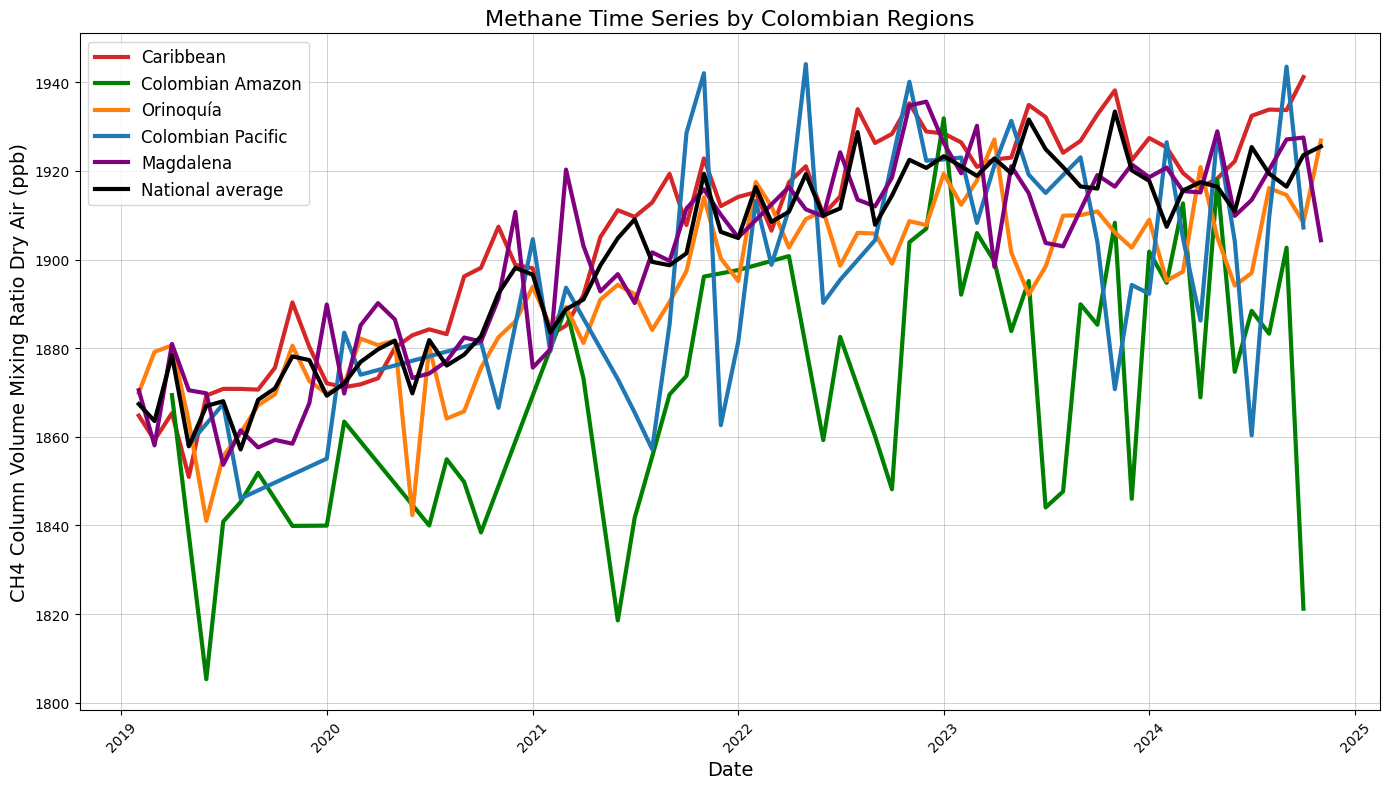

In [24]:
# Create the figure and axis
plt.figure(figsize=(14, 8))
ax = plt.gca()

# Set title and labels
title = 'Methane Time Series by Colombian Regions'
plt.title(title, fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('CH4 Column Volume Mixing Ratio Dry Air (ppb)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()

# Add grids
plt.grid(True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.5)
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.2)

# Custom labels for clusters
labels = ["Caribbean", "Colombian Amazon", "Orinoquía", "Colombian Pacific", "Magdalena", "National average"]
sns_colors = sns.color_palette("tab10")
colors = [sns_colors[3], "green", sns_colors[1], sns_colors[0], "purple", "black"]
# Plot time series for each cluster
numberOfClusters = 5
for i in range(numberOfClusters):
    cluster_i_all_data = getClusterData(df_allDataFiltered, df_clusteredMeanData, i)
    getTimeSeriesPlot(cluster_i_all_data, i, ax, labels, color=colors[i])
# national prom graph
getTimeSeriesPlot(df_allDataFiltered, 5, ax, labels, color='black')
# Add legend
plt.legend(loc='best', fontsize=12)

# Improve layout and show plot
plt.tight_layout()
plt.show()

In [83]:
sns.color_palette("tab10")

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

In [50]:
barbados = pd.read_csv('CH4_completo.csv')
barbados = barbados[(barbados['value']>1850)*(barbados['year']>2018)]
barbados['date'] = pd.to_datetime(barbados[['year', 'month', 'day']])
barbados = barbados.drop(['day', 'month', 'year', 'site_code', 'hour', 'minute', 'second', 'time_decimal', 'method', 'event_number', 'instrument', 'qcflag', 'analysis_datetime', 'datetime'], axis=1)
barbados

,air_sample_container_id,value,value_unc,latitude,longitude,altitude,elevation,intake_height,date
3068,2867-99,1900.11,907.0,13165,-59432,20.0,15.0,5.0,2019-01-06
3069,2868-99,1900.72,907.0,13165,-59432,20.0,15.0,5.0,2019-01-06
3070,3957-99,1882.45,907.0,13165,-59432,20.0,15.0,5.0,2019-01-13
3071,3958-99,1881.57,907.0,13165,-59432,20.0,15.0,5.0,2019-01-13
3072,5555-99,1887.30,907.0,13165,-59432,20.0,15.0,5.0,2019-01-20
...,...,...,...,...,...,...,...,...,...
3549,4583-99,1978.37,575.0,13165,-59432,20.0,15.0,5.0,2023-12-17
3550,2905-99,1976.85,575.0,13165,-59432,20.0,15.0,5.0,2023-12-24
3551,2952-99,1976.83,575.0,13165,-59432,20.0,15.0,5.0,2023-12-24
3552,3457-99,1970.39,575.0,13165,-59432,20.0,15.0,5.0,2023-12-31


In [51]:
global_mean = pd.read_csv('ch4_mm_gl.csv')
global_mean = global_mean[global_mean['year']>2018]
global_mean['date'] = pd.to_datetime(global_mean[['year', 'month']].assign(day=1))
global_mean = global_mean.drop(['month', 'decimal', 'year', 'trend'], axis=1)
global_mean

,average,average_unc,trend_unc,date
426,1865.01,1.05,0.68,2019-01-01
427,1865.01,0.92,0.65,2019-02-01
428,1866.31,0.92,0.63,2019-03-01
429,1865.34,0.57,0.61,2019-04-01
430,1861.97,1.17,0.58,2019-05-01
...,...,...,...,...
491,1921.55,-9.99,-9.99,2024-06-01
492,1920.84,-9.99,-9.99,2024-07-01
493,1926.35,-9.99,-9.99,2024-08-01
494,1936.23,-9.99,-9.99,2024-09-01


In [19]:
def getTimeSeriesPlot(df, value,cluster_label, ax, labels, color=None):
    """
    Plots a time series of monthly averages for a given cluster with custom labels.
    """
    # Ensure the dataframe is sorted by date
    df = df.sort_values('date')
    
    # Extract year and month from the date column
    df['year_month'] = df['date'].dt.to_period('M')  # Group by year and month
    
    # Calculate the monthly average
    monthly_avg = df.groupby('year_month')[value].mean().reset_index()
    
    # Convert 'year_month' back to datetime for plotting
    monthly_avg['year_month'] = monthly_avg['year_month'].dt.to_timestamp()
    
    
    if color == None:
        # Plot the monthly average time series with custom labels
        sns.lineplot(data=monthly_avg, x='year_month', y=value, 
                    label=labels[cluster_label], ax=ax, linewidth=2 )
    else:
        sns.lineplot(data=monthly_avg, x='year_month', y=value, 
                   label=labels[cluster_label], ax=ax, color=color, linewidth=2)

In [52]:
scaling_factor = 1.0395307027448444
df_allDataFiltered['CH4_column_volume_mixing_ratio_dry_air_bias_corrected_scaled'] = df_allDataFiltered['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']*scaling_factor

In [70]:
def getTimeSeriesPlot(df, cluster_label, ax, labels, color=None, add_trend=True, add_confidence=True, 
                      enso_data=None, highlight_events=None):
    """
    Plots a time series of monthly averages for a given cluster with enhanced visualization features.
    
    Parameters:
    -----------
    df : DataFrame
        The dataframe containing methane data.
    cluster_label : int
        The index of the cluster to plot.
    ax : matplotlib.axes.Axes
        The axis to plot on.
    labels : list
        List of labels for each cluster.
    color : str, optional
        The color for the line plot.
    add_trend : bool, optional
        Whether to add a trend line.
    add_confidence : bool, optional
        Whether to add confidence intervals.
    enso_data : DataFrame, optional
        DataFrame containing ENSO index values.
    highlight_events : list, optional
        List of tuples (date, label) for notable events to highlight.
    """
    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from scipy import stats
    from statsmodels.nonparametric.smoothers_lowess import lowess
    
    # Ensure the dataframe is sorted by date
    df = df.sort_values('date')
    
    # Extract year and month from the date column
    df['year_month'] = df['date'].dt.to_period('M')  # Group by year and month
    
    # Calculate the monthly average and standard deviation
    monthly_stats = df.groupby('year_month')['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].agg(
        ['mean', 'std', 'count']).reset_index()
    
    # Calculate confidence intervals (95%)
    monthly_stats['ci_95'] = 1.96 * monthly_stats['std'] / np.sqrt(monthly_stats['count'])
    monthly_stats['upper_ci'] = monthly_stats['mean'] + monthly_stats['ci_95']
    monthly_stats['lower_ci'] = monthly_stats['mean'] - monthly_stats['ci_95']
    
    # Convert 'year_month' back to datetime for plotting
    monthly_stats['year_month'] = monthly_stats['year_month'].dt.to_timestamp()
    
    # Determine the color for the plot
    if labels[cluster_label] == "Colombian Amazon":
        color = "green"
    elif color is None:
        color = f"C{cluster_label}"
    
    # Plot the monthly average time series
    line = sns.lineplot(data=monthly_stats, x='year_month', y='mean', 
                        label=labels[cluster_label], ax=ax, color=color, linewidth=2.5)
    
    # Add confidence intervals if requested
    if add_confidence:
        ax.fill_between(monthly_stats['year_month'], 
                         monthly_stats['lower_ci'],
                         monthly_stats['upper_ci'],
                         color=color, alpha=0.2)
    
    # Add trend line if requested
    if add_trend and len(monthly_stats) > 2:
        # Use LOWESS smoothing for the trend
        x_numeric = np.array(range(len(monthly_stats)))
        y = monthly_stats['mean'].values
        
        # Fit LOWESS model
        lowess_result = lowess(y, x_numeric, frac=0.3)
        
        # Plot trend line
        ax.plot(monthly_stats['year_month'], lowess_result[:, 1], 
                '--', linewidth=1.5, color=color, alpha=0.7)
        
        # Calculate and add linear trend (for rate of change)
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_numeric, y)
        annual_rate = slope * 12  # convert monthly to annual rate
        
        # Add annotation for rate of change (if significant)
        if p_value < 0.05:
            # Find position for text (near the end of the line)
            x_pos = monthly_stats['year_month'].iloc[-1]
            y_pos = monthly_stats['mean'].iloc[-1]
            
            # Format the rate as +/- X.XX ppb/yr
            rate_text = f"{annual_rate:.2f} ppb/yr"
            if annual_rate > 0:
                rate_text = "+" + rate_text
            
            # Add text with small offset
            ax.text(x_pos, y_pos, rate_text, color=color, fontsize=8, 
                    ha='right', va='bottom', bbox=dict(facecolor='white', alpha=0.7, pad=2))
    
    # Highlight specific events if provided
    if highlight_events:
        for event_date, event_label in highlight_events:
            if event_date >= monthly_stats['year_month'].min() and event_date <= monthly_stats['year_month'].max():
                ax.axvline(x=event_date, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
                ax.text(event_date, ax.get_ylim()[1] * 0.95, event_label, rotation=90, 
                        ha='left', va='top', fontsize=8, bbox=dict(facecolor='white', alpha=0.7, pad=2))
    
    return line

def create_enso_dataframe(enso_table):
    """
    Convert ENSO table data to a pandas DataFrame with proper date format.
    
    Parameters:
    -----------
    enso_table : str or DataFrame
        The ENSO data table as string or DataFrame.
        
    Returns:
    --------
    DataFrame
        DataFrame with 'date' and 'enso_index' columns.
    """
    import pandas as pd
    import io
    
    # If input is a string, parse it
    if isinstance(enso_table, str):
        # Clean and parse the table
        lines = enso_table.strip().split('\n')
        header = lines[0].split('|')
        header = [h.strip() for h in header if h.strip()]
        
        data = []
        for line in lines[2:]:  # Skip header and separator lines
            if '|' in line:
                values = line.split('|')
                values = [v.strip() for v in values if v.strip()]
                if len(values) >= 13:  # Year + 12 months
                    year = int(values[0])
                    for month, value in enumerate(values[1:13], 1):
                        if value.strip():
                            data.append([year, month, float(value)])
    
    # If input is already a DataFrame, ensure it has the right format
    else:
        # Assuming enso_table has 'Year' and monthly columns
        enso_table = enso_table.melt(id_vars=['Year'], var_name='Month', value_name='enso_index')
        # Convert month names to numbers if needed
        month_map = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6, 
                     'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
        if enso_table['Month'].dtype == object:
            enso_table['Month'] = enso_table['Month'].map(month_map)
        
        data = enso_table[['Year', 'Month', 'enso_index']].values.tolist()
    
    # Create DataFrame from parsed data
    enso_df = pd.DataFrame(data, columns=['year', 'month', 'enso_index'])
    
    # Convert to datetime
    enso_df['date'] = pd.to_datetime(enso_df[['year', 'month']].assign(day=1))
    
    return enso_df

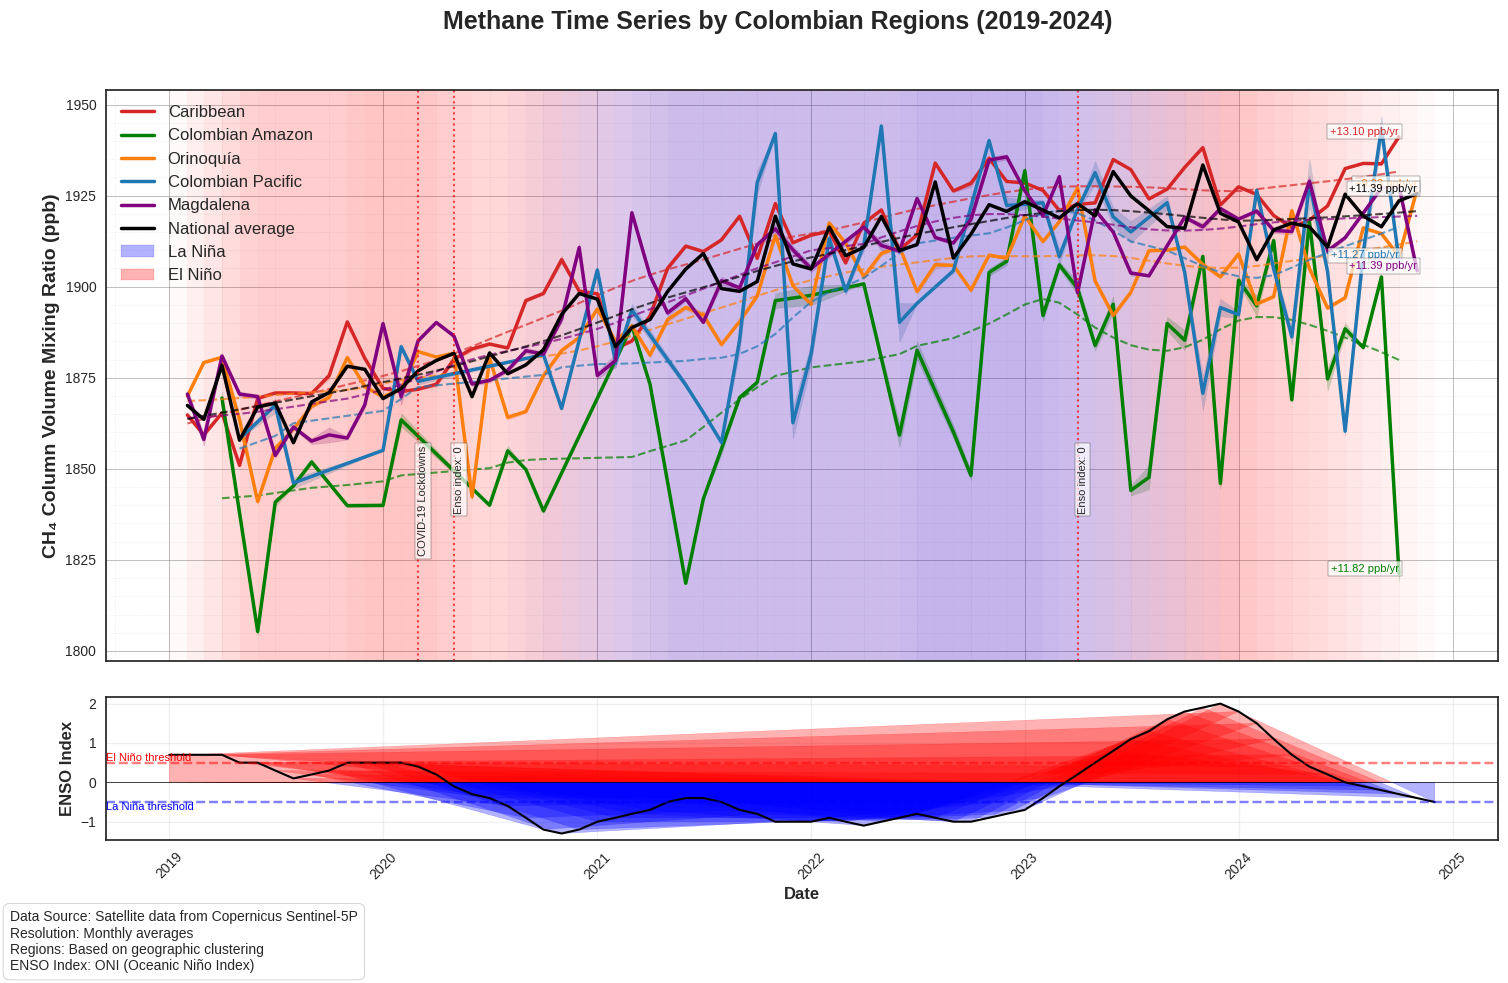

In [ ]:
def setup_methane_timeseries_plot(df_allDataFiltered, df_clusteredMeanData, enso_data=None, regions=None, 
                                 add_national_avg=True, highlight_events=None, start_date=None, end_date=None):
    """
    Creates a comprehensive methane time series plot with multiple enhancements.
    
    Parameters:
    -----------
    df_allDataFiltered : DataFrame
        Filtered dataframe with all methane data.
    df_clusteredMeanData : DataFrame
        Dataframe with clustered mean data.
    enso_data : str or DataFrame, optional
        ENSO index data to use for highlighting El Niño/La Niña periods.
    regions : list, optional
        List of region indices to include in the plot.
    add_national_avg : bool, optional
        Whether to add the national average.
    highlight_events : list, optional
        List of tuples (date, label) for notable events to highlight.
    start_date : datetime, optional
        Start date for the plot.
    end_date : datetime, optional
        End date for the plot.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    import matplotlib.dates as mdates
    import pandas as pd
    import numpy as np
    from matplotlib.ticker import MultipleLocator
    import matplotlib.patches as mpatches
    
    # Create the figure and axis
    fig = plt.figure(figsize=(16, 10))
    
    # Create a gridspec for the main plot and the ENSO index subplot
    gs = fig.add_gridspec(2, 1, height_ratios=[4, 1], hspace=0.1)
    ax = fig.add_subplot(gs[0])
    
    # If ENSO data is provided, create a second subplot for it
    if enso_data is not None:
        enso_ax = fig.add_subplot(gs[1], sharex=ax)
        enso_df = create_enso_dataframe(enso_data)
    else:
        enso_ax = None
    
    # Filter by date range if specified
    if start_date or end_date:
        date_mask = pd.Series(True, index=df_allDataFiltered.index)
        if start_date:
            date_mask &= df_allDataFiltered['date'] >= pd.Timestamp(start_date)
        if end_date:
            date_mask &= df_allDataFiltered['date'] <= pd.Timestamp(end_date)
        df_allDataFiltered = df_allDataFiltered[date_mask]
    
    # Custom labels and colors for clusters
    full_labels = ["Caribbean", "Colombian Amazon", "Orinoquía", "Colombian Pacific", "Magdalena", "National average"]
    sns_colors = sns.color_palette("tab10")
    colors = [sns_colors[3], "green", sns_colors[1], sns_colors[0], "purple", "black"]
    
    # Determine which regions to plot
    if regions is None:
        regions = range(5)  # Plot all regions by default
    
    # Plot each selected region
    for i in regions:
        cluster_i_all_data = getClusterData(df_allDataFiltered, df_clusteredMeanData, i)
        if len(cluster_i_all_data) > 0:  # Only plot if data exists
            getTimeSeriesPlot(cluster_i_all_data, i, ax, full_labels, color=colors[i])
    
    # Add national average if requested
    if add_national_avg:
        getTimeSeriesPlot(df_allDataFiltered, 5, ax, full_labels, color='black', 
                         add_confidence=False, highlight_events=highlight_events)
    
    # Calculate overall statistics
    years = df_allDataFiltered['date'].dt.year.unique()
    year_min, year_max = min(years), max(years)
    overall_mean = df_allDataFiltered['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].mean()
    
    # Set title and labels with enhanced information
    title = f'Methane Time Series by Colombian Regions ({year_min}-{year_max})'
    #subtitle = f'Mean concentration: {overall_mean:.2f} ppb'
    plt.suptitle(title, fontsize=18, fontweight='bold')
    #ax.set_title(subtitle, fontsize=14)
    
    ax.set_xlabel('', fontsize=14)  # Remove x-label from top plot
    ax.set_ylabel('CH₄ Column Volume Mixing Ratio (ppb)', fontsize=14, fontweight='bold')
    
    # Format x-axis to show years clearly
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    plt.setp(ax.get_xticklabels(), visible=False)  # Hide x-tick labels on top plot
    
    # Format y-axis with appropriate scaling
    ax.yaxis.set_major_locator(MultipleLocator(25))
    ax.yaxis.set_minor_locator(MultipleLocator(5))
    
    # Add enhanced grid
    ax.grid(True, which='major', linestyle='-', linewidth=0.7, color='gray', alpha=0.5)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.2)
    
    # Add a horizontal line for global average methane (approximate 2020 value)
    # global_avg = 1875  # Global average methane in 2020 (adjust as needed)
    # ax.axhline(y=global_avg, color='red', linestyle='--', linewidth=1, alpha=0.7)
    # ax.text(ax.get_xlim()[0], global_avg + 2, f'Global Average (~{global_avg} ppb)', 
    #         color='red', fontsize=10, va='bottom', ha='left',
    #        bbox=dict(facecolor='white', alpha=0.7, pad=2))
    
    # If ENSO data is provided, add ENSO index subplot and highlight periods
    if enso_data is not None and enso_ax is not None:
        # Plot ENSO index
        enso_df = create_enso_dataframe(enso_data)
        
        # Plot ENSO index line
        sns.lineplot(x='date', y='enso_index', data=enso_df, ax=enso_ax, color='black', linewidth=1.5)
        
        # Fill areas for El Niño (red) and La Niña (blue)
        enso_ax.fill_between(enso_df['date'], enso_df['enso_index'], 0, 
                            where=(enso_df['enso_index'] > 0), 
                            interpolate=True, color='red', alpha=0.3)
        enso_ax.fill_between(enso_df['date'], enso_df['enso_index'], 0, 
                            where=(enso_df['enso_index'] < 0), 
                            interpolate=True, color='blue', alpha=0.3)
        
        # Highlight the same regions in the main plot with different intensities
        for i in range(len(enso_df) - 1):
            current_date = enso_df.iloc[i]['date']
            next_date = enso_df.iloc[i+1]['date']
            enso_value = enso_df.iloc[i]['enso_index']
            
            # Add shaded areas to main plot based on ENSO index
            if enso_value <= -0.5:  # Strong La Niña (blue)
                ax.axvspan(current_date, next_date, alpha=0.02, color='blue')
            elif enso_value >= 0.5:  # Strong El Niño (red)
                ax.axvspan(current_date, next_date, alpha=0.02, color='red')
        
        # Configure ENSO subplot
        enso_ax.set_ylabel('ENSO Index', fontsize=12, fontweight='bold')
        enso_ax.set_xlabel('Date', fontsize=12, fontweight='bold')
        enso_ax.grid(True, alpha=0.3)
        enso_ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        
        # Add horizontal lines for El Niño/La Niña thresholds
        enso_ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
        enso_ax.axhline(y=-0.5, color='blue', linestyle='--', alpha=0.5)
        
        # Add text labels for thresholds
        enso_ax.text(enso_ax.get_xlim()[0], 0.5, 'El Niño threshold', 
                     color='red', va='bottom', ha='left', fontsize=8)
        enso_ax.text(enso_ax.get_xlim()[0], -0.5, 'La Niña threshold', 
                     color='blue', va='top', ha='left', fontsize=8)
        
        # Format x-axis
        enso_ax.xaxis.set_major_locator(mdates.YearLocator())
        enso_ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(enso_ax.get_xticklabels(), rotation=45)
        
        # Add ENSO patches to legend
        nina_patch = mpatches.Patch(color='blue', alpha=0.3, label='La Niña')
        nino_patch = mpatches.Patch(color='red', alpha=0.3, label='El Niño')
    
    # Add enhanced legend with better positioning and formatting
    handles, labels = ax.get_legend_handles_labels()
    if enso_data is not None:
        handles.extend([nina_patch, nino_patch])
    
    legend = ax.legend(handles=handles, loc='upper left', fontsize=12, 
                      framealpha=0.9, edgecolor='gray')
    legend.get_frame().set_linewidth(0.8)
    
    # Add a text box with study information
    info_text = (
        "Data Source: Satellite data from Copernicus Sentinel-5P\n"
        "Resolution: Monthly averages\n"
        "Regions: Based on geographic clustering\n"
        "ENSO Index: ONI (Oceanic Niño Index)"
    )
    plt.figtext(0.02, 0.02, info_text, fontsize=10, ha='left', 
               bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))
    
    # Improve layout and adjust margins
    plt.subplots_adjust(bottom=0.15, top=0.9, right=0.95, left=0.08)
    
    return ax, enso_ax

# Example usage:
enso_data = pd.DataFrame({
    'Year': [2019, 2020, 2021, 2022, 2023, 2024],
    'Jan': [0.7, 0.5, -1.0, -1.0, -0.7, 1.8],
    'Feb': [0.7, 0.5, -0.9, -0.9, -0.4, 1.5],
    'Mar': [0.7, 0.4, -0.8, -1.0, -0.1, 1.1],
    'Apr': [0.7, 0.2, -0.7, -1.1, 0.2, 0.7],
    'May': [0.5, -0.1, -0.5, -1.0, 0.5, 0.4],
    'Jun': [0.5, -0.3, -0.4, -0.9, 0.8, 0.2],
    'Jul': [0.3, -0.4, -0.4, -0.8, 1.1, 0.0],
    'Aug': [0.1, -0.6, -0.5, -0.9, 1.3, -0.1],
    'Sep': [0.2, -0.9, -0.7, -1.0, 1.6, -0.2],
    'Oct': [0.3, -1.2, -0.8, -1.0, 1.8, -0.3],
    'Nov': [0.5, -1.3, -1.0, -0.9, 1.9, -0.4],
    'Dec': [0.5, -1.2, -1.0, -0.8, 2.0, -0.5]
})

notable_events = [
    (pd.Timestamp('2020-03-01'), 'COVID-19 Lockdowns'),
    (pd.Timestamp('2020-05-01'), 'Enso index: 0'),
    (pd.Timestamp('2023-04-01'), 'Enso index: 0')
]

# Create the enhanced plot with ENSO data
ax, enso_ax = setup_methane_timeseries_plot(
    df_allDataFiltered=df_allDataFiltered, 
    df_clusteredMeanData=df_clusteredMeanData,
    highlight_events=notable_events,
    enso_data=enso_data
)

plt.savefig('colombia_methane_timeseries_enhanced.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_416755/2136388449.py:96: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-white')


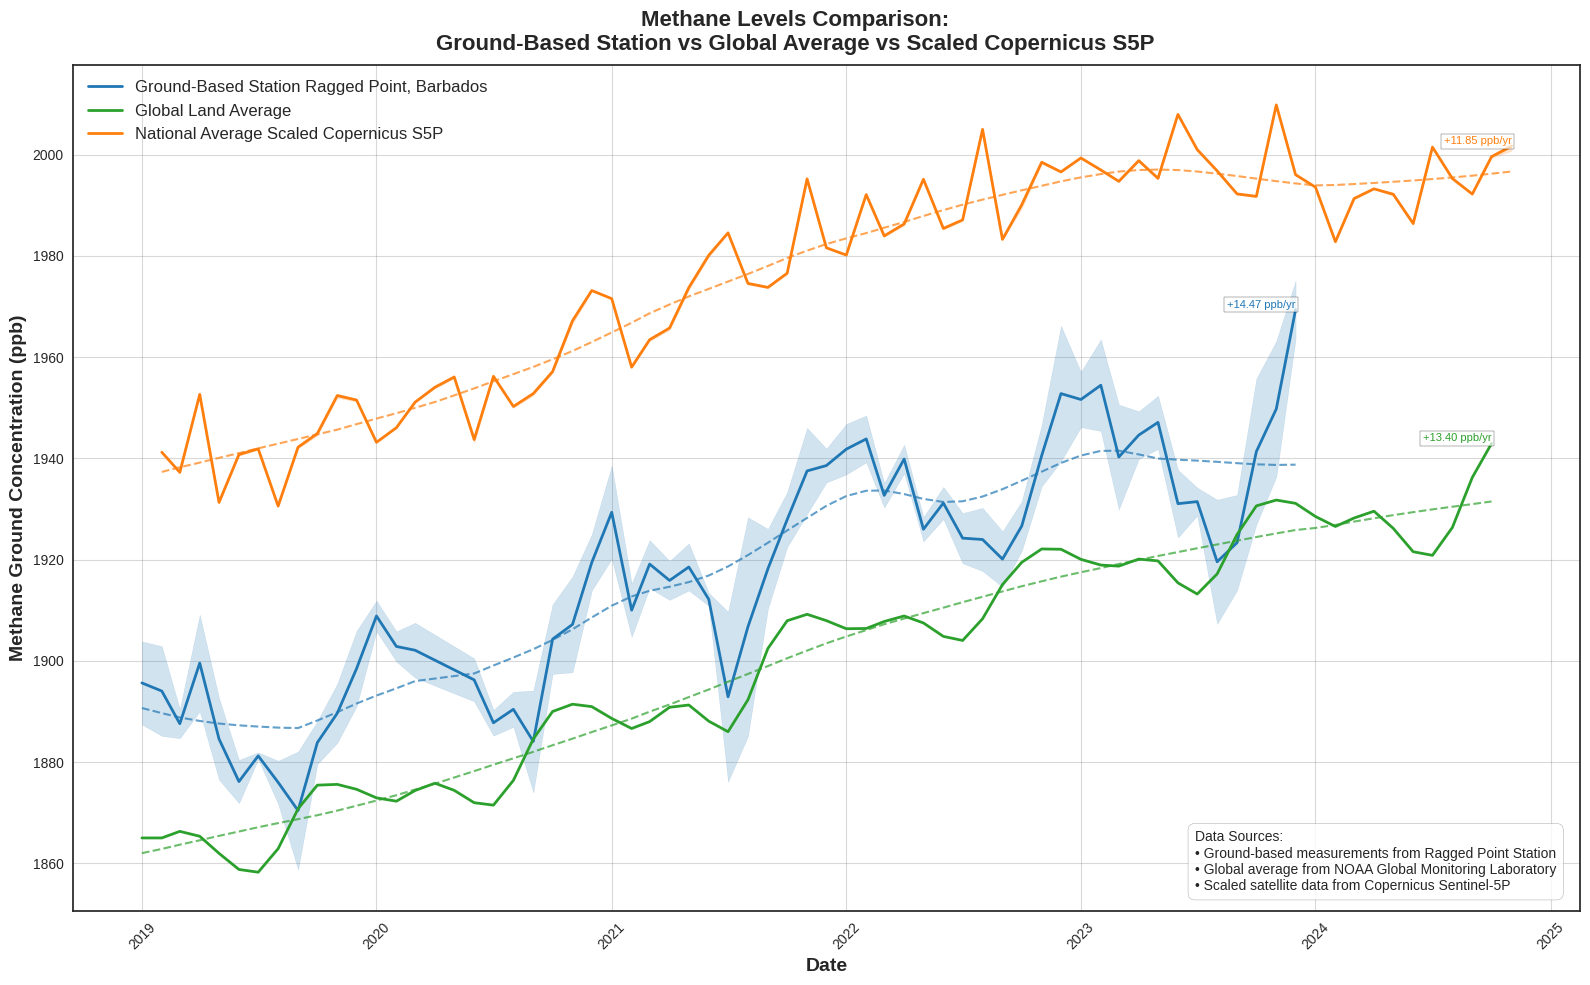

In [75]:
def getTimeSeriesPlot(df, value, cluster_label, ax, labels, color=None, add_trend=True, add_confidence=True):
    """
    Plots a time series of monthly averages with enhanced visualization features.
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe with date and value columns
    value : str
        Column name for the value to plot
    cluster_label : int
        Index for the label
    ax : matplotlib.axes
        Axis to plot on
    labels : list
        List of labels for the legend
    color : str, optional
        Color for the line plot
    add_trend : bool, optional
        Whether to add trend line
    add_confidence : bool, optional
        Whether to add confidence intervals
    """
    import numpy as np
    from scipy import stats
    from statsmodels.nonparametric.smoothers_lowess import lowess
    
    # Ensure the dataframe is sorted by date
    df = df.sort_values('date')
    
    # Extract year and month
    df['year_month'] = df['date'].dt.to_period('M')
    
    # Calculate monthly statistics
    monthly_stats = df.groupby('year_month')[value].agg(['mean', 'std', 'count']).reset_index()
    
    # Calculate confidence intervals (95%)
    monthly_stats['ci_95'] = 1.96 * monthly_stats['std'] / np.sqrt(monthly_stats['count'])
    monthly_stats['upper_ci'] = monthly_stats['mean'] + monthly_stats['ci_95']
    monthly_stats['lower_ci'] = monthly_stats['mean'] - monthly_stats['ci_95']
    
    # Convert 'year_month' back to datetime
    monthly_stats['year_month'] = monthly_stats['year_month'].dt.to_timestamp()
    
    # Plot main line
    line = sns.lineplot(data=monthly_stats, x='year_month', y='mean',
                       label=labels[cluster_label], ax=ax,
                       color=color if color else f"C{cluster_label}",
                       linewidth=2)
    
    # Add confidence intervals if requested
    if add_confidence:
        ax.fill_between(monthly_stats['year_month'],
                       monthly_stats['lower_ci'],
                       monthly_stats['upper_ci'],
                       color=color if color else f"C{cluster_label}",
                       alpha=0.2)
    
    # Add trend line if requested
    if add_trend and len(monthly_stats) > 2:
        # Use LOWESS smoothing for the trend
        x_numeric = np.array(range(len(monthly_stats)))
        y = monthly_stats['mean'].values
        
        # Fit LOWESS model
        lowess_result = lowess(y, x_numeric, frac=0.3)
        
        # Plot trend line
        ax.plot(monthly_stats['year_month'], lowess_result[:, 1],
                '--', linewidth=1.5,
                color=color if color else f"C{cluster_label}",
                alpha=0.7)
        
        # Calculate and add linear trend
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_numeric, y)
        annual_rate = slope * 12  # convert monthly to annual rate
        
        # Add annotation for rate of change (if significant)
        if p_value < 0.05:
            x_pos = monthly_stats['year_month'].iloc[-1]
            y_pos = monthly_stats['mean'].iloc[-1]
            
            rate_text = f"{annual_rate:.2f} ppb/yr"
            if annual_rate > 0:
                rate_text = "+" + rate_text
            
            ax.text(x_pos, y_pos, rate_text,
                   color=color if color else f"C{cluster_label}",
                   fontsize=8, ha='right', va='bottom',
                   bbox=dict(facecolor='white', alpha=0.7, pad=2))
    
    return line

import matplotlib.dates as mdates
# Create main plot
plt.style.use('seaborn-white')
fig, ax = plt.subplots(figsize=(16, 10))

# Set title and labels with enhanced formatting
title = 'Methane Levels Comparison:\nGround-Based Station vs Global Average vs Scaled Copernicus S5P'
plt.suptitle(title, fontsize=16, fontweight='bold')

# Add subtitle with date range
# date_range = f"({pd.to_datetime(barbados['date'].min()).year}-{pd.to_datetime(barbados['date'].max()).year})"
# plt.title(date_range, fontsize=14)

plt.xlabel('Date', fontsize=14, fontweight='bold')
plt.ylabel('Methane Ground Concentration (ppb)', fontsize=14, fontweight='bold')

# Custom labels and colors
labels = ["Ground-Based Station Ragged Point, Barbados",
          "Global Land Average",
          "National Average Scaled Copernicus S5P"]
colors = ['#1f77b4', '#2ca02c', '#ff7f0e']  # Custom colors

# Plot each dataset
getTimeSeriesPlot(barbados, 'value', 0, ax, labels, color=colors[0])
getTimeSeriesPlot(global_mean, 'average', 1, ax, labels, color=colors[1])
getTimeSeriesPlot(df_allDataFiltered, 
                  'CH4_column_volume_mixing_ratio_dry_air_bias_corrected_scaled',
                  2, ax, labels, color=colors[2])

# Enhance grid
ax.grid(True, which='major', linestyle='-', linewidth=0.8, color='gray', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', linewidth=0.5, color='gray', alpha=0.2)

# Format x-axis
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Add legend with enhanced formatting
legend = plt.legend(loc='upper left', fontsize=12, framealpha=0.9, edgecolor='gray')
legend.get_frame().set_linewidth(0.8)

# Add information box
info_text = (
    "Data Sources:\n"
    "• Ground-based measurements from Ragged Point Station\n"
    "• Global average from NOAA Global Monitoring Laboratory\n"
    "• Scaled satellite data from Copernicus Sentinel-5P"
)
plt.figtext(0.75, 0.1, info_text, fontsize=10, ha='left',
           bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray',
                    boxstyle='round,pad=0.5'))

# Improve layout
plt.tight_layout()

# Save and show plot
plt.savefig('methane_comparison_enhanced_barbados.png', dpi=300, bbox_inches='tight')
plt.show()